#### Importing Necessary Libraries

In [0]:
from pyspark.sql.functions import col
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import unix_timestamp
from pyspark.sql.functions import lit
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import hour, dayofweek, month, year
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.sql.functions import monotonically_increasing_id, col
from pyspark.sql.functions import monotonically_increasing_id
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

## PART 3: Machine Learning (Continues)

In [0]:
# Reading the combined file
final_combined_df = spark.read.parquet("/dbfs/taxi_data/combined_gy_taxi.parquet")

final_combined_df.createOrReplaceTempView("final_combined_taxi")

#### Dataset Splitting

In [0]:
train_df = final_combined_df.filter(~((year("pickup_datetime") == 2022) & (month("pickup_datetime").between(10, 12))))

test_df = final_combined_df.filter((year("pickup_datetime") == 2022) & (month("pickup_datetime").between(10, 12)))

#### Data Preprocessing and Feature Engineering

##### Selecting Features

In [0]:
selected_features = [
    "passenger_count", "trip_distance", "payment_type", "PU_Borough", "DO_Borough", "taxi_color", "total_amount"
]

train_df = train_df.select(selected_features)
test_df = test_df.select(selected_features)

#### Preprocessing Pipeline

In [0]:
categorical_cols = ["PU_Borough", "DO_Borough", "payment_type", "taxi_color"]

indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_index", handleInvalid="keep") for col in categorical_cols]

encoders = [OneHotEncoder(inputCol=f"{col}_index", outputCol=f"{col}_encoded") for col in categorical_cols]

feature_cols = ["trip_distance", "passenger_count"]
encoded_feature_cols = [f"{col}_encoded" for col in categorical_cols]
feature_cols += encoded_feature_cols

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

preprocessing_stages = indexers + encoders + [assembler]
preprocessing_pipeline = Pipeline(stages=preprocessing_stages)

#### Splitting Data into Smaller Chunks

#### Chunk 1

In [0]:
fraction = 1 / 50000
train_small_df = train_df.sample(fraction=fraction, seed=42)
test_small_df = test_df.sample(fraction=fraction, seed=42)

Train chunk size: 6705, Test chunk size: 918


In [0]:
train_small_df.show(5)

+---------------+-------------+------------+----------+----------+----------+------------+
|passenger_count|trip_distance|payment_type|PU_Borough|DO_Borough|taxi_color|total_amount|
+---------------+-------------+------------+----------+----------+----------+------------+
|            1.0|         1.08|         1.0| Manhattan| Manhattan|    yellow|        7.56|
|            1.0|         16.8|         1.0| Manhattan|    Queens|    yellow|       68.34|
|            1.0|          0.8|         1.0| Manhattan| Manhattan|    yellow|        7.55|
|            1.0|          1.6|         2.0| Manhattan| Manhattan|    yellow|        10.8|
|            1.0|         3.43|         2.0| Manhattan| Manhattan|    yellow|        17.3|
+---------------+-------------+------------+----------+----------+----------+------------+
only showing top 5 rows



In [0]:
test_small_df.show(10)

+---------------+-------------+------------+----------+----------+----------+------------+
|passenger_count|trip_distance|payment_type|PU_Borough|DO_Borough|taxi_color|total_amount|
+---------------+-------------+------------+----------+----------+----------+------------+
|            1.0|         3.76|         1.0| Manhattan| Manhattan|    yellow|       23.16|
|            1.0|          5.4|         1.0| Manhattan| Manhattan|    yellow|       26.18|
|            1.0|         0.98|         1.0| Manhattan| Manhattan|    yellow|         9.8|
|            5.0|         0.83|         1.0| Manhattan| Manhattan|    yellow|        11.3|
|            1.0|         1.33|         1.0| Manhattan| Manhattan|    yellow|       18.96|
|            1.0|         1.44|         1.0| Manhattan| Manhattan|    yellow|       14.12|
|            1.0|         0.56|         1.0| Manhattan| Manhattan|    yellow|        9.96|
|            1.0|         2.17|         4.0| Manhattan| Manhattan|    yellow|       -13.8|

##### Fit the Preprocessing Pipeline on Chunk 1

In [0]:
preprocessing_model1 = preprocessing_pipeline.fit(train_small_df)

train_preprocessed_df1 = preprocessing_model1.transform(train_small_df)
test_preprocessed_df1 = preprocessing_model1.transform(test_small_df)

In [0]:
train_preprocessed_df1.select("features").show(5, truncate=False)

+------------------------------------------------+
|features                                        |
+------------------------------------------------+
|(21,[0,1,2,8,15,19],[1.08,1.0,1.0,1.0,1.0,1.0]) |
|(21,[0,1,2,10,15,19],[16.8,1.0,1.0,1.0,1.0,1.0])|
|(21,[0,1,2,8,15,19],[0.8,1.0,1.0,1.0,1.0,1.0])  |
|(21,[0,1,2,8,16,19],[1.6,1.0,1.0,1.0,1.0,1.0])  |
|(21,[0,1,2,8,16,19],[3.43,1.0,1.0,1.0,1.0,1.0]) |
+------------------------------------------------+
only showing top 5 rows



In [0]:
test_preprocessed_df1.select("features").show(5, truncate=False)

+-----------------------------------------------+
|features                                       |
+-----------------------------------------------+
|(21,[0,1,2,8,15,19],[3.76,1.0,1.0,1.0,1.0,1.0])|
|(21,[0,1,2,8,15,19],[5.4,1.0,1.0,1.0,1.0,1.0]) |
|(21,[0,1,2,8,15,19],[0.98,1.0,1.0,1.0,1.0,1.0])|
|(21,[0,1,2,8,15,19],[0.83,5.0,1.0,1.0,1.0,1.0])|
|(21,[0,1,2,8,15,19],[1.33,1.0,1.0,1.0,1.0,1.0])|
+-----------------------------------------------+
only showing top 5 rows



##### Linear Regression Model on Chunk 1

In [0]:
linear_regression1 = LinearRegression(featuresCol="features", labelCol="total_amount")

linear_regression_model1 = linear_regression1.fit(train_preprocessed_df1)

In [0]:
linear_regression_model1.write().overwrite().save("/dbfs/taxi_data/linear_regression_model1")

##### Random Forest Regressor Model on Chunk 1

In [0]:
random_forest1 = RandomForestRegressor(featuresCol="features", labelCol="total_amount", maxDepth=5, numTrees=50)

random_forest_model1 = random_forest1.fit(train_preprocessed_df1)

In [0]:
random_forest_model1.write().overwrite().save("/dbfs/taxi_data/random_forest_model1")

##### Evaluate the Linear Regression Model for Chunk 1

In [0]:
predictions_lr1 = linear_regression_model1.transform(test_preprocessed_df1)

In [0]:
# Display the columns in the predictions DataFrame
print(predictions_lr1.columns)

# Show a few rows of the predictions DataFrame
predictions_lr1.select("features", "total_amount", "prediction").show(10)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(21,[0,1,2,8,15,1...|       23.16|20.593467350813842|
|(21,[0,1,2,8,15,1...|       26.18| 26.28222142900238|
|(21,[0,1,2,8,15,1...|         9.8|10.950335437786922|
|(21,[0,1,2,8,15,1...|        11.3|10.215221461464708|
|(21,[0,1,2,8,15,1...|       18.96|12.164398808132038|
|(21,[0,1,2,8,15,1...|       14.12|12.545961581669074|
|(21,[0,1,2,8,15,1...|        9.96| 9.493459393372785|
|(21,[0,1,2,8,18,1...|       -13.8|3.1031771171006746|
|(21,[0,1,2,8,15,1...|       14.76|12.754086730871094|
|(21,[0,1,2,8,15,1...|       35

In [0]:
evaluator1 = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="rmse")

rmse_lr1 = evaluator1.evaluate(predictions_lr1)
print(f"Linear Regression Model RMSE for first chunk: {rmse_lr1}")

Linear Regression Model RMSE for first chunk: 6.782220328540334


##### Saving the Prediction results of Linear Regression Model on Chunk 1 

In [0]:
output_path_parquet = "/dbfs/taxi_data/predictions_lr1.parquet"

predictions_lr1.write.mode("overwrite").parquet(output_path_parquet)


##### Evaluate the Random Forest Model for Chunk 1

In [0]:
predictions_rf1 = random_forest_model1.transform(test_preprocessed_df1)

In [0]:
print(predictions_rf1.columns)

predictions_rf1.select("features", "total_amount", "prediction").show(10)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(21,[0,1,2,8,15,1...|       23.16| 18.07167572620561|
|(21,[0,1,2,8,15,1...|       26.18| 19.18236000768743|
|(21,[0,1,2,8,15,1...|         9.8|11.854817232885404|
|(21,[0,1,2,8,15,1...|        11.3|11.868553934337028|
|(21,[0,1,2,8,15,1...|       18.96|12.661341851500342|
|(21,[0,1,2,8,15,1...|       14.12|12.661341851500342|
|(21,[0,1,2,8,15,1...|        9.96| 11.67743262587263|
|(21,[0,1,2,8,18,1...|       -13.8|  9.80867073426779|
|(21,[0,1,2,8,15,1...|       14.76|12.749378886546559|
|(21,[0,1,2,8,15,1...|       35

In [0]:
evaluator2 = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="rmse")

rmse_rf1 = evaluator2.evaluate(predictions_rf1)
print(f"Random Forest Model RMSE for first chunk: {rmse_rf1}")

Random Forest Model RMSE for first chunk: 7.874490546672597


#### Chunk 2

In [0]:
fraction = 1 / 10000
train_med_df = train_df.sample(fraction=fraction, seed=42)
test_med_df = test_df.sample(fraction=fraction, seed=42)

##### Fit the Preprocessing Pipeline on Chunk 2

In [0]:
preprocessing_model2 = preprocessing_pipeline.fit(train_med_df)

train_preprocessed_df2 = preprocessing_model2.transform(train_med_df)
test_preprocessed_df2 = preprocessing_model2.transform(test_med_df)

##### Linear Regression Model on Chunk 2

In [0]:
linear_regression_model2 = linear_regression1.fit(train_preprocessed_df2)

##### Random Forest Regressor Model on Chunk 2

In [0]:
random_forest_model2 = random_forest1.fit(train_preprocessed_df2)

##### Evaluate the Linear Regression Model for Chunk 2

In [0]:
predictions_lr2 = linear_regression_model2.transform(test_preprocessed_df2)

In [0]:
print(predictions_lr2.columns)
predictions_lr2.select("features", "total_amount", "prediction").show(5)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(21,[0,1,2,8,15,1...|        16.3|17.092306166883073|
|(21,[0,1,2,8,15,1...|       10.56| 9.718965272376042|
|(21,[0,1,2,8,15,1...|       34.55|29.345106955417446|
|(21,[0,1,2,8,16,1...|        11.3| 9.768189968562634|
|(21,[0,1,2,8,15,1...|       23.16|20.568628104198222|
+--------------------+------------+------------------+
only showing top 5 rows



In [0]:
rmse_lr2 = evaluator1.evaluate(predictions_lr2)
print(f"Linear Regression Model RMSE for second chunk: {rmse_lr2}")

Linear Regression Model RMSE for second chunk: 6.534028191137997


##### Evaluate the Random Forest Model for Chunk 2

In [0]:
predictions_rf2 = random_forest_model2.transform(test_preprocessed_df2)

In [0]:
print(predictions_rf2.columns)

predictions_rf2.select("features", "total_amount", "prediction").show(5)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(21,[0,1,2,8,15,1...|        16.3|17.286813415942316|
|(21,[0,1,2,8,15,1...|       10.56|11.744781420502191|
|(21,[0,1,2,8,15,1...|       34.55|20.838958271382584|
|(21,[0,1,2,8,16,1...|        11.3| 10.56849944719055|
|(21,[0,1,2,8,15,1...|       23.16| 18.10817589049786|
+--------------------+------------+------------------+
only showing top 5 rows



In [0]:
rmse_rf2 = evaluator2.evaluate(predictions_rf2)
print(f"Random Forest Model RMSE for second chunk: {rmse_rf2}")

Random Forest Model RMSE for second chunk: 7.8573787936926545


#### Chunk 3

In [0]:
fraction = 1 / 1000
train_large_df = train_df.sample(fraction=fraction, seed=42)
test_large_df = test_df.sample(fraction=fraction, seed=42)

##### Fit the Preprocessing Pipeline on Chunk 3

In [0]:
preprocessing_model3 = preprocessing_pipeline.fit(train_large_df)

train_preprocessed_df3 = preprocessing_model3.transform(train_large_df)
test_preprocessed_df3 = preprocessing_model3.transform(test_large_df)

##### Linear Regression Model on Chunk 3

In [0]:
linear_regression_model3 = linear_regression1.fit(train_preprocessed_df3)

##### Random Forest Regressor Model on Chunk 3

In [0]:
random_forest_model3 = random_forest1.fit(train_preprocessed_df3)

##### Evaluate the Linear Regression Model for Chunk 3

In [0]:
predictions_lr3 = linear_regression_model3.transform(test_preprocessed_df3)

In [0]:
print(predictions_lr3.columns)
predictions_lr3.select("features", "total_amount", "prediction").show(5)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(23,[0,1,2,9,16,2...|        21.8|21.877652619827558|
|(23,[0,1,2,9,17,2...|        26.3|18.561915628007007|
|(23,[0,1,2,9,16,2...|       18.48|13.401138072711118|
|(23,[0,1,2,9,16,2...|        16.3|17.055722784131568|
|(23,[0,1,2,9,17,2...|        20.3| 12.18730102956578|
+--------------------+------------+------------------+
only showing top 5 rows



In [0]:
rmse_lr3 = evaluator1.evaluate(predictions_lr3)
print(f"Linear Regression Model RMSE for third chunk: {rmse_lr3}")

Linear Regression Model RMSE for third chunk: 6.671988987207609


##### Evaluate the Random Forest Model for Chunk 3

In [0]:
predictions_rf3 = random_forest_model3.transform(test_preprocessed_df3)

In [0]:
print(predictions_rf3.columns)

predictions_rf3.select("features", "total_amount", "prediction").show(5)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(23,[0,1,2,9,16,2...|        21.8| 19.58592559004685|
|(23,[0,1,2,9,17,2...|        26.3|16.621078556792316|
|(23,[0,1,2,9,16,2...|       18.48|12.425922798734234|
|(23,[0,1,2,9,16,2...|        16.3|18.010168098233795|
|(23,[0,1,2,9,17,2...|        20.3| 11.53432765598759|
+--------------------+------------+------------------+
only showing top 5 rows



In [0]:
rmse_rf3 = evaluator2.evaluate(predictions_rf3)
print(f"Random Forest Model RMSE for third chunk: {rmse_rf3}")

Random Forest Model RMSE for third chunk: 7.6340459755875125


#### Chunk 4

In [0]:
fraction = 1 / 100
train_larger_df = train_df.sample(fraction=fraction, seed=42)
test_larger_df = test_df.sample(fraction=fraction, seed=42)

##### Fit the Preprocessing Pipeline on Chunk 4

In [0]:
preprocessing_model4 = preprocessing_pipeline.fit(train_larger_df)

train_preprocessed_df4 = preprocessing_model4.transform(train_larger_df)
test_preprocessed_df4 = preprocessing_model4.transform(test_larger_df)

##### Linear Regression Model on Chunk 4

In [0]:
linear_regression_model4 = linear_regression1.fit(train_preprocessed_df4)

##### Random Forest Regressor Model on Chunk 4

In [0]:
random_forest_model4 = random_forest1.fit(train_preprocessed_df4)

##### Evaluate the Linear Regression Model for Chunk 4

In [0]:
predictions_lr4 = linear_regression_model4.transform(test_preprocessed_df4)

In [0]:
print(predictions_lr4.columns)
predictions_lr4.select("features", "total_amount", "prediction").show(5)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(23,[0,1,2,9,16,2...|        17.8|13.434083546550916|
|(23,[0,1,2,9,16,2...|       11.76| 9.046465083457418|
|(23,[0,1,2,9,16,2...|       21.95|12.743622384614167|
|(23,[0,1,2,9,16,2...|       15.36|13.399560488454078|
|(23,[0,1,2,9,17,2...|        12.3|10.096252232376532|
+--------------------+------------+------------------+
only showing top 5 rows



In [0]:
rmse_lr4 = evaluator1.evaluate(predictions_lr4)
print(f"Linear Regression Model RMSE for fourth chunk: {rmse_lr4}")

Linear Regression Model RMSE for fourth chunk: 6.898009173614721


##### Evaluate the Random Forest Model for Chunk 4

In [0]:
predictions_rf4 = random_forest_model4.transform(test_preprocessed_df4)

In [0]:
print(predictions_rf4.columns)

predictions_rf4.select("features", "total_amount", "prediction").show(5)

['passenger_count', 'trip_distance', 'payment_type', 'PU_Borough', 'DO_Borough', 'taxi_color', 'total_amount', 'PU_Borough_index', 'DO_Borough_index', 'payment_type_index', 'taxi_color_index', 'PU_Borough_encoded', 'DO_Borough_encoded', 'payment_type_encoded', 'taxi_color_encoded', 'features', 'prediction']
+--------------------+------------+------------------+
|            features|total_amount|        prediction|
+--------------------+------------+------------------+
|(23,[0,1,2,9,16,2...|        17.8|12.587716274713866|
|(23,[0,1,2,9,16,2...|       11.76|11.980646056523188|
|(23,[0,1,2,9,16,2...|       21.95|12.587716274713866|
|(23,[0,1,2,9,16,2...|       15.36|12.587716274713866|
|(23,[0,1,2,9,17,2...|        12.3|10.296819506442553|
+--------------------+------------+------------------+
only showing top 5 rows



In [0]:
rmse_rf4 = evaluator2.evaluate(predictions_rf4)
print(f"Random Forest Model RMSE for fourth chunk: {rmse_rf4}")

Random Forest Model RMSE for fourth chunk: 7.839862390382443


-----------

### Visualize Prediction Comparisons

In [0]:
rmse_data = pd.DataFrame({
    'Chunk': ['Chunk 1', 'Chunk 2', 'Chunk 3', 'Chunk 4'],
    'Linear Regression RMSE': [rmse_lr1, rmse_lr2, rmse_lr3, rmse_lr4],
    'Random Forest RMSE': [rmse_rf1, rmse_rf2, rmse_rf3, rmse_rf4]
})

print(rmse_data)

     Chunk  Linear Regression RMSE  Random Forest RMSE
0  Chunk 1                6.782220            7.874491
1  Chunk 2                6.534028            7.857379
2  Chunk 3                6.671989            7.634046
3  Chunk 4                6.898009            7.839862


##### RMSE Comparison between Linear Regression and Random Forest models

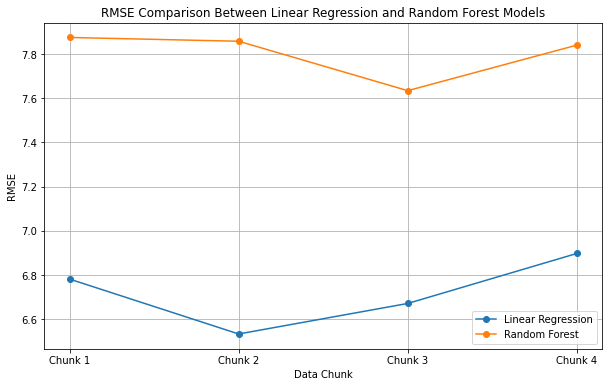

In [0]:
plt.figure(figsize=(10, 6))
plt.plot(rmse_data['Chunk'], rmse_data['Linear Regression RMSE'], label='Linear Regression', marker='o')
plt.plot(rmse_data['Chunk'], rmse_data['Random Forest RMSE'], label='Random Forest', marker='o')

plt.title('RMSE Comparison Between Linear Regression and Random Forest Models')
plt.xlabel('Data Chunk')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

##### Prediction Results Comparisons

In [0]:
combined_predictions_lr = predictions_lr1.union(predictions_lr2).union(predictions_lr3).union(predictions_lr4)

combined_predictions_rf = predictions_rf1.union(predictions_rf2).union(predictions_rf3).union(predictions_rf4)


/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field PU_Borough_encoded. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field PU_Borough_encoded. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to A

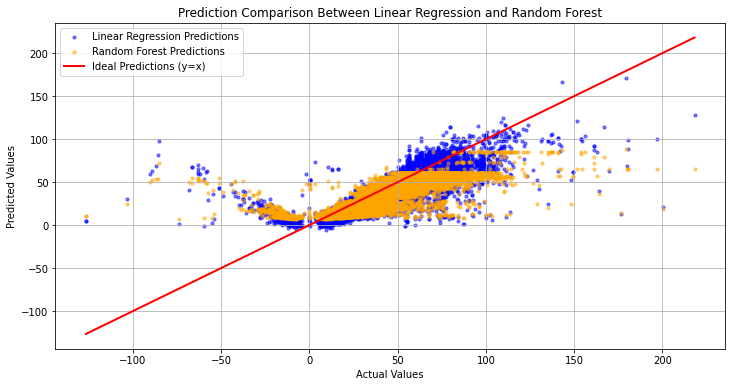

In [0]:
combined_predictions_lr_pd = combined_predictions_lr.toPandas()
combined_predictions_rf_pd = combined_predictions_rf.toPandas()

plt.figure(figsize=(12, 6))

# Scatter plot for Linear Regression predictions
plt.scatter(combined_predictions_lr_pd['total_amount'], combined_predictions_lr_pd['prediction'], 
            alpha=0.5, label='Linear Regression Predictions', color='blue', s=10)

# Scatter plot for Random Forest predictions
plt.scatter(combined_predictions_rf_pd['total_amount'], combined_predictions_rf_pd['prediction'], 
            alpha=0.5, label='Random Forest Predictions', color='orange', s=10)

plt.plot([combined_predictions_lr_pd['total_amount'].min(), combined_predictions_lr_pd['total_amount'].max()], 
         [combined_predictions_lr_pd['total_amount'].min(), combined_predictions_lr_pd['total_amount'].max()], 
         color='red', lw=2, label='Ideal Predictions (y=x)')

plt.title('Prediction Comparison Between Linear Regression and Random Forest')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In most of the cases, the Linear Regression model's predictions are closer to the actual values, indicating better performance.